虽然计算量是 O( $𝑁^2$) ，但内存访问（HBM ↔ SRAM）才是实际瓶颈。GPU 的 SRAM（如 A100 的 192KB/流处理器）比 HBM 快得多，但容量极小。

- 让我用一个交互式可视化来深入解释为什么内存访问（而非计算量）是注意力机制的瓶颈，以及 FlashAttention 如何通过"分块+重计算"策略解决这个问题。

# 🚀 为什么内存访问是瓶颈？GPU 存储层次详解
从 A100 硬件架构出发，理解 FlashAttention 的设计动机



In [1]:
from IPython.display import Image

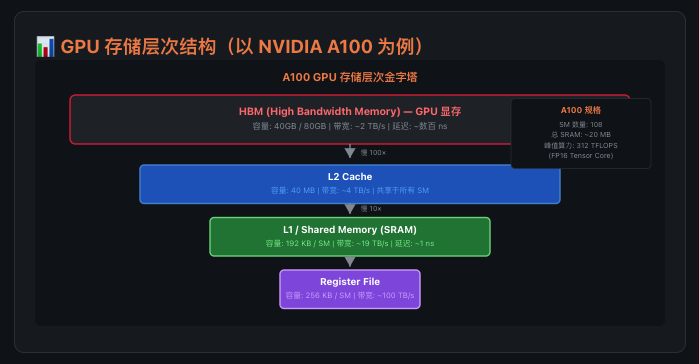

In [2]:
Image(filename='./image/fa1.png')

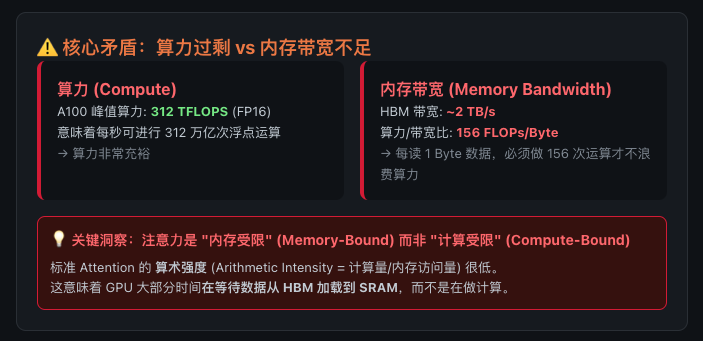

In [3]:
Image(filename='./image/fa2.png')

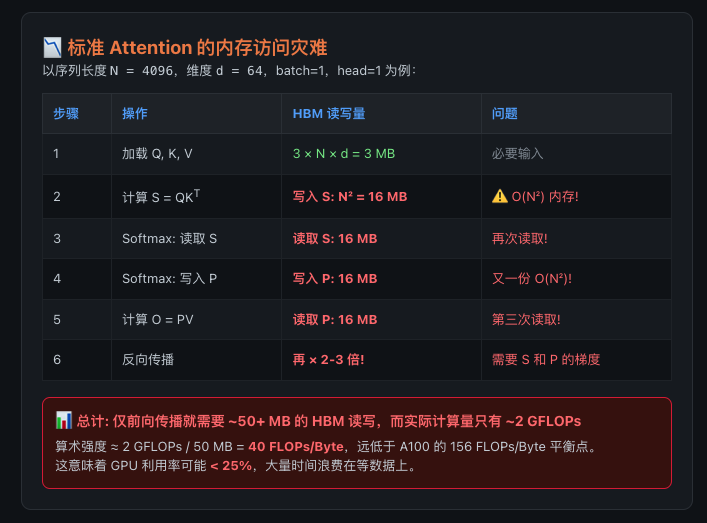

In [7]:
Image(filename='./image/fa3.png')

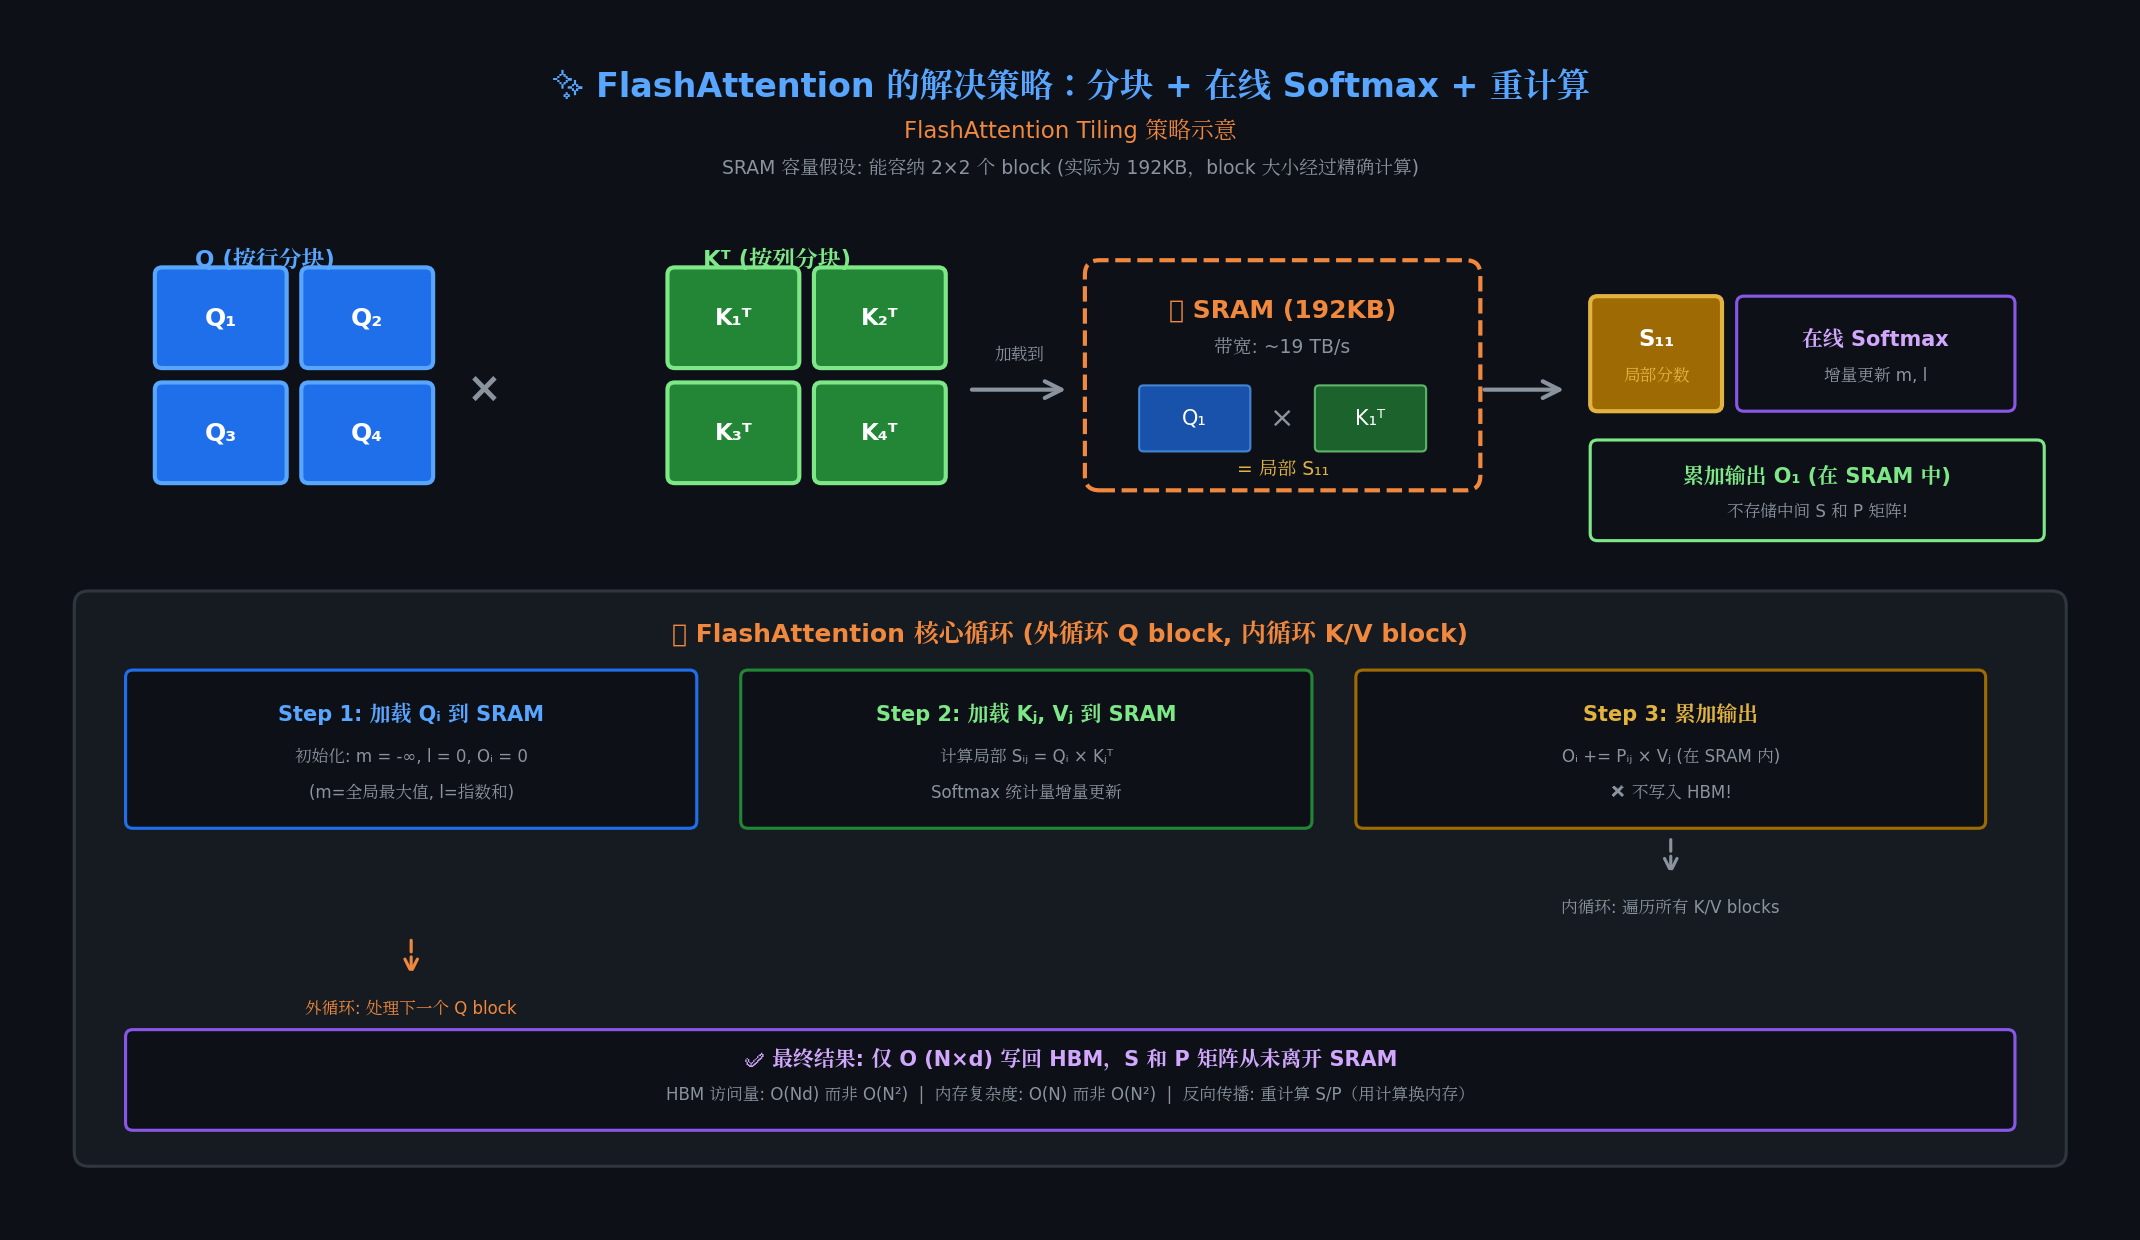

In [6]:
Image(filename='./image/flashattention_tiling.png')

T (按列分块) K₁ᵀ K₂ᵀ K₃ᵀ K₄ᵀ 加载到 🔥 SRAM (192KB) 带宽: ~19 TB/s Q₁ × K₁ᵀ S₁₁ 局部分数 在线 Softmax 增量更新 m, l 累加输出 O₁ (在 SRAM 中) 不存储中间 S 和 P 矩阵!

🔄 FlashAttention 核心循环 (外循环 Q block, 内循环 K/V block) 

- Step 1: 加载 Qᵢ 到 SRAM 初始化: m = -∞, l = 0, Oᵢ = 0 (m=最大值, l=指数和) 

- Step 2: 加载 Kⱼ, Vⱼ 到 SRAM 计算局部 Sᵢⱼ = Qᵢ × Kⱼᵀ Softmax 统计量增量更新 

- Step 3: 累加输出 Oᵢ += Pᵢⱼ × Vⱼ (在 SRAM) 不写入 HBM! 

- ✅ 最终结果: 仅 O (N×d) 写回 HBM，S 和 P 矩阵从未离开 SRAM HBM 访问量: O(Nd) 而非 O(N²) | 内存复杂度: O(N) 而非 O(N²) 反向传播: 不存储 S/P，而是重新计算（用计算换内存）

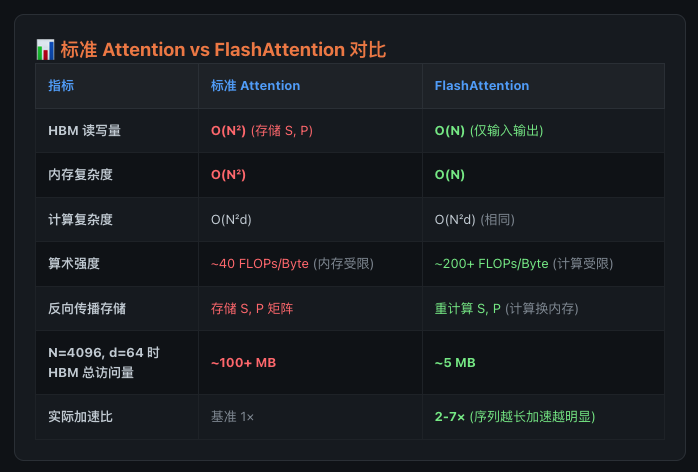

In [5]:
Image(filename='./image/fa4.png')

# GPU 存储层次的"速度悬崖"

| 存储层级                          | A100 规格    | 带宽        | 延迟       | 与上一层速度比 |
| ----------------------------- | ---------- | --------- | -------- | ------- |
| **Register File**             | 256 KB/SM  | ~100 TB/s | ~1 cycle | —       |
| **L1 / Shared Memory (SRAM)** | 192 KB/SM  | ~19 TB/s  | ~1 ns    | 慢 5×    |
| **L2 Cache**                  | 40 MB (共享) | ~4 TB/s   | ~10 ns   | 慢 5×    |
| **HBM (显存)**                  | 40/80 GB   | ~2 TB/s   | ~数百 ns   | 慢 10×   |

## 关键数字：
- A100 有 108 个 SM，总 SRAM 仅约 20 MB，而 HBM 有 40-80 GB。SRAM 速度快 10 倍，但容量只有 HBM 的 0.05%。

# 为什么标准 Attention 是"内存受限"的？
## 算术强度 (Arithmetic Intensity)
算术强度= $\frac{计算量 (FLOPs)}{内存访问量 (Bytes)}$

  
- A100 的平衡点：~156 FLOPs/Byte（FP16 Tensor Core）
  - 低于此值 → <font color='red'>内存受限（GPU 等数据）</font>
  - 高于此值 → 计算受限（GPU 满负荷运算）
## 标准 Attention 的算术强度
以 N=4096,d=64  为例：

| 操作                  | 计算量                | HBM 访问量                  | 算术强度       |
| ------------------- | ------------------ | ------------------------ | ---------- |
| $S = QK^T$          | $2N^2d$ ≈ 2 GFLOPs | 读 Q,K (2MB) + 写 S (64MB) | **~30** ❌  |
| $\text{Softmax}(S)$ | $O(N^2)$           | 读 S (64MB) + 写 P (64MB)  | **~0.1** ❌ |
| $O = PV$            | $2N^2d$ ≈ 2 GFLOPs | 读 P,V (65MB) + 写 O (1MB) | **~30** ❌  |

<font color='red'>整体算术强度 ≈ 40 FLOPs/Byte，远低于 156 的平衡点。这意味着 GPU 利用率可能不足 25%。</font>

# FlashAttention 的"IO-Aware"设计
FlashAttention 的核心洞察来自论文中的IO 复杂度分析：
- 标准 Attention 的 HBM 访问次数：Θ(Nd+$N^2$) 
- FlashAttention 的 HBM 访问次数：Θ(Nd) 

FlashAttention 通过三个关键技术实现这一目标：

## 1. Tiling（分块）
$将 Q,K,V  切成大小为 B_r×d  和 B_c×d  的 blocks$，使得：
- <font color='red'>一个 Q  block + 一个 K  block + 一个 V  block 能同时放入 SRAM</font>
- $B_r,B_c$经过精确计算，确保不超出 192KB 限制

## 2. Online Softmax（在线 Softmax）
- <font color='red'>传统 softmax 需要看到全部 N  个值：</font>
softmax(x 

  
- <font color='blue'>FlashAttention 使用增量式更新：</font>
设已处理部分的最大值为 m ，指数和为 ℓ ，新 block 到来时：
$m_{new} = max(m_{old},m_{block})$

$ℓ_{new} = ℓ_{old} ⋅ e^{m_{old}-m_{new}} + ℓ_{block} ⋅ e{m_{block}-m_{new}}$

  
<font color='blue'>这样可以在不存储完整 P  矩阵的情况下，逐步累加输出 O 。</font>

## 3. Recomputation（重计算）
反向传播时:
- <font color='blue'>标准 Attention 需要存储 S  和 P  矩阵来计算梯度。</font>

- FlashAttention 的策略：
  - <font color='blue'>不存储 S  和 P </font>
  - <font color='red'>重新计算：利用保存的 softmax 统计量（m,ℓ ）重新运行前向逻辑</font>
  - 虽然多了一次前向计算，但大幅减少了 HBM 读写，总体更快

# 类比理解
想象你在厨房做饭：

| 场景                 | 类比                               |
| ------------------ | -------------------------------- |
| **HBM**            | 冰箱（容量大，但拿东西慢）                    |
| **SRAM**           | 灶台旁边的操作台（容量小，但随手可取）              |
| **标准 Attention**   | 每次切菜都跑回冰箱拿食材，切完又放回冰箱，下次用再拿       |
| **FlashAttention** | 一次性从冰箱取出所有需要的食材放在操作台上，全部处理完再放回冰箱 |


FlashAttention 的"分块"就是把大任务拆成操作台能容纳的小批次，"在线 softmax"就是在操作台上直接完成调味，不需要把半成品放回冰箱。


# SRAM

SRAM（Static Random-Access Memory，静态随机存取存储器） 是计算机和电子系统中非常关键的一种半导体存储器。
- 简单来说，<font color='red'>只要保持通电，它里面存储的数据就能一直稳定存在</font>，<font color='blue'>不需要像 DRAM（动态随机存取存储器）那样定期“刷新”来维持数据</font>。

为了让你全面了解 SRAM，我整理了它的核心特点、工作原理以及主要应用场景：

##  核心工作原理：为什么叫“静态”？
SRAM 的基本存储单元通常由 6 个晶体管（6T） 组成（即两个交叉耦合的反相器加上两个访问晶体管）。
- 双稳态电路：这 6 个晶体管构成了一个具有两个稳定状态的电路，分别代表二进制的 0 和 1。
- <font color='red'>无需刷新：只要电源不中断，这个电路就会一直保持在当前状态</font>，<font color='blue'>因此不需要像 DRAM 那样通过电容充放电并周期性刷新来保存数据。这也是它被称为“静态”的原因。</font>

##  主要优缺点

| 维度 | 优势 | 劣势 |
| :--- | :--- | :--- |
| 速度 | 极快。访问时间短，无需等待刷新周期，读写延迟极低。 | - |
| 功耗 | 活跃时功耗较低（因为不需要刷新电流）。 | 待机/漏电流：随着制程微缩，静态漏电流增加，导致整体功耗管理变难。 |
| 集成度 | - | 密度低、面积大。6T 结构比 DRAM 的 1T1C 结构占用硅片面积大得多，导致单位容量成本高。 |
| 接口 | 接口简单，无需复杂的刷新控制逻辑。 | - |



## 主要应用场景

由于 SRAM 速度快但成本高、密度低，它通常不会用作系统的主内存（那是 DRAM 的领地），而是用于对速度要求极高的地方：
1. CPU 缓存（Cache）：<font color='red'>这是 SRAM 最大的应用领域。L1、L2、L3 缓存几乎全部由 SRAM 构成，用于缓解 CPU 与主内存之间的速度鸿沟。</font>
2. 寄存器文件（Register Files）：CPU 内部最顶级的存储。
3. 网络设备：路由器、交换机中的高速数据包缓冲和转发表。
4. 嵌入式系统：如微控制器（MCU）内部的小容量片上内存、FPGA 内部的配置存储或逻辑块。
5. 消费电子：数码相机、硬盘驱动器中的高速缓冲。

##  SRAM vs. DRAM：一张表看懂区别

| 特性 | SRAM (静态) | DRAM (动态) |
| :--- | :--- | :--- |
| 存储单元 | 6 个晶体管 (6T) | 1 个晶体管 + 1 个电容 (1T1C) |
| 数据保持 | 通电即保持，无需刷新 | <font color='red'>电容会漏电，必须定期刷新</font> |
| 速度 | 极快 (纳秒级) | 较慢 (需要刷新和预充电时间) |
| 密度/成本 | 低密度 / 昂贵 | 高密度 / 便宜 |
| 典型用途 | CPU Cache, 嵌入式缓冲 | 电脑/手机主内存 (DDR4/DDR5) |

## 补充知识
- 非易失性 SRAM (nvSRAM)：
  - 结合了 SRAM 的高速和 EEPROM/Flash 的非易失性。断电时，数据会自动从 SRAM 转移到内部的非易失性存储单元中，通电后自动恢复。常用于需要掉电数据保护的关键系统。
- 异步 vs. 同步：
  - 早期的 SRAM 是异步的（地址变了数据就变），现代高性能 SRAM 大多是同步的（Sync SRAM），由时钟信号控制读写，以便更好地配合高速 CPU。

# 